# Exercise 5 – Hypothesis Testing

This notebook solves Exercise 5 using the EFIplus Mediterranean dataset.

Main analyses:
1. Comparison of Mean Annual Temperature between Brown Trout presence and absence sites
2. Chi-square test of independence between Brown Trout occurrence and country
3. One-way ANOVA for upstream catchment elevation among the 8 most sampled catchments
4. Kruskal–Wallis test as the non-parametric equivalent of ANOVA

In [4]:
%pip install plotly statsmodels scikit-posthocs nbformat ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys
print(sys.executable)

c:\Users\Aster\AppData\Local\Programs\Python\Python311\python.exe


In [6]:
import sys
!"{sys.executable}" -m pip install nbformat ipython


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import nbformat
import IPython

print("nbformat version:", nbformat.__version__)
print("IPython works")

nbformat version: 5.10.4
IPython works


In [8]:
import pandas as pd
import numpy as np
import zipfile
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import scikit_posthocs as sp

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [9]:
zip_path = "EFIplus_medit.zip"
extract_folder = "efi_data"

if not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

csv_path = os.path.join(extract_folder, "EFIplus_medit.csv")

df = pd.read_csv(csv_path, sep=";")
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,Geomorph2,Geomorph3,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Barriers_catchment_down,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,Impoundment,Hydropeaking,Water_abstraction,Hydro_mod,Temperature_impact,Velocity_increase,Reservoir_flushing,Sedimentation,Channelisation,Cross_sec,Instream_habitat,Riparian_vegetation,Embankment,Floodprotection,Floodplain,Toxic_substances,Acidification,Water_quality_index,Eutrophication,Organic_pollution,Organic_siltation,Sum of Run1_number_all,Total_sp,Abramis brama,Achondrostoma arcasii,Achondrostoma occidentale,Achondrostoma oligolepis,Acipenser naccarii,Alburnoides bipunctatus,Alburnus albidus,Alburnus alburnus,Alosa alosa,Alosa fallax,Ameiurus melas,Anaecypris hispanica,Anguilla anguilla,Atherina boyeri,Australoheros facetus,Barbatula barbatula,Barbatula quignardi,Barbus barbus,Barbus bocagei,Barbus comizo,Barbus graellsii,Barbus haasi,Barbus meridionalis,Barbus microcephalus,Barbus plebejus,Barbus sclateri,Barbus tyberinus,Blicca bjoerkna,Carassius auratus,Carassius carassius,Chelon labrosus,Chondrostoma genei,Chondrostoma nasus,Chondrostoma soetta,Chondrostoma toxostoma,Cobitis calderoni,Cobitis paludica,Cobitis taenia,Cottus gobio,Cottus hispaniolensis,Cyprinus carpio,Dicentrarchus labrax,Esox lucius,Gambusia affinis,Gambusia holbrooki,Gasterosteus aculeatus,Gasterosteus gymnurus,Gobio gobio,Gobio lozanoi,Gymnocephalus cernuus,Hypophthalmichthys molitrix,Iberochondrostoma almacai,Iberochondrostoma lemmingii,Iberochondrostoma lusitanicum,Lampetra fluviatilis,Lampetra planeri,Lepomis gibbosus,Leuciscus cephalus,Leuciscus leuciscus,Leuciscus lucumonis,Leuciscus souffia,Liza aurata,Liza ramada,Luciobarbus guiraonis,Micropterus salmoides,Mugil cephalus,Oncorhynchus mykiss,Pachychilon pictum,Padogobius martensii,Padogobius nigricans,Parachondrostoma arrigonis,Parachondrostoma miegii,Parachondrostoma turiense,Perca fluviatilis,Petromyzon marinus,Phoxinus bigerri,Phoxinus phoxinus,Platichthys flesus,Pseudochondrostoma duriense,Pseudochondrostoma polylepis,Pseudochondrostoma willkommii,Pseudorasbora parva,Rhodeus amarus,Rutilus aula,Rutilus rubilio,Rutilus rutilus,Salaria fluviatilis,Salmo salar,Salmo trutta fario,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius alburnoides,Squalius aradensis,Squalius carolitertii,Squalius laietanus,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,1,1,-0.047266,-1.039638,0.451016,Pluvial,Permanent,199,Siliceous,0.001,3.0,700.840807,522.071164,17.6,8.5,28.1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,1.0,1.0,1.0,1,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,1,1,0.389648,-0.443332,0.489422,Groundwater,Permanent,1253,Calcareous,13.406,3.0,1603.519424,640.327779,9.3,0.6,18.9,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1

In [10]:
print(df.shape)
print(df.columns.tolist())

(5011, 164)
['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication'

In [11]:
# Keep only relevant columns
cols = [
    "Country",
    "Catchment_name",
    "Elevation_mean_catch",
    "temp_ann",
    "Salmo trutta fario"
]

data = df[cols].copy()

# Rename fish column to something easier to type
data = data.rename(columns={"Salmo trutta fario": "brown_trout"})

# Convert to numeric where needed
data["temp_ann"] = pd.to_numeric(data["temp_ann"], errors="coerce")
data["Elevation_mean_catch"] = pd.to_numeric(data["Elevation_mean_catch"], errors="coerce")
data["brown_trout"] = pd.to_numeric(data["brown_trout"], errors="coerce")

# Drop missing values only where needed later
data.head()

,Country,Catchment_name,Elevation_mean_catch,temp_ann,brown_trout
0,Spain,Guadalquivir,700.840807,17.6,0
1,Spain,Tejo,1603.519424,9.3,1
2,Spain,Tejo,1578.678579,10.1,1
3,Spain,Tejo,1553.219128,10.1,1
4,Spain,Tejo,1539.684999,10.3,1


In [12]:
data["trout_presence"] = data["brown_trout"].map({1: "Presence", 0: "Absence"})
data["trout_presence"].value_counts(dropna=False)

trout_presence
Presence    3035
Absence     1976
Name: count, dtype: int64

PART D — Exercise 5, Question 1

In [13]:
q1 = data[["temp_ann", "trout_presence"]].dropna().copy()

presence = q1[q1["trout_presence"] == "Presence"]["temp_ann"]
absence  = q1[q1["trout_presence"] == "Absence"]["temp_ann"]

print("Presence n =", len(presence))
print("Absence n  =", len(absence))

Presence n = 2941
Absence n  = 1900


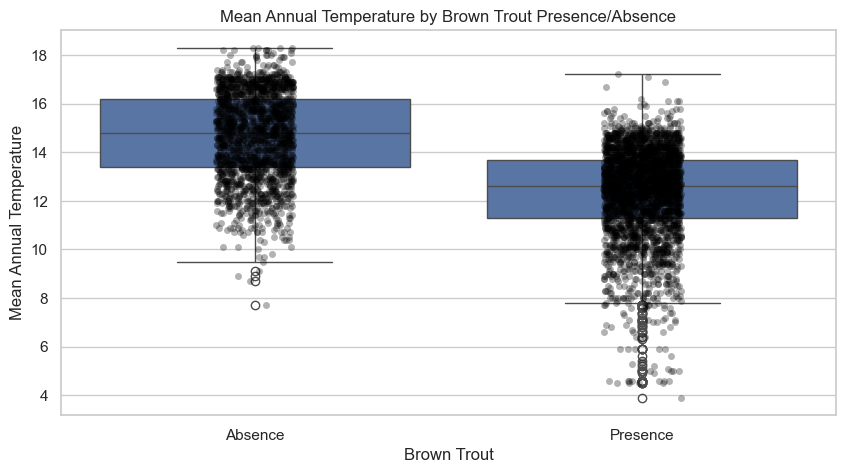

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=q1, x="trout_presence", y="temp_ann")
sns.stripplot(data=q1, x="trout_presence", y="temp_ann", color="black", alpha=0.3)
plt.title("Mean Annual Temperature by Brown Trout Presence/Absence")
plt.xlabel("Brown Trout")
plt.ylabel("Mean Annual Temperature")
plt.show()

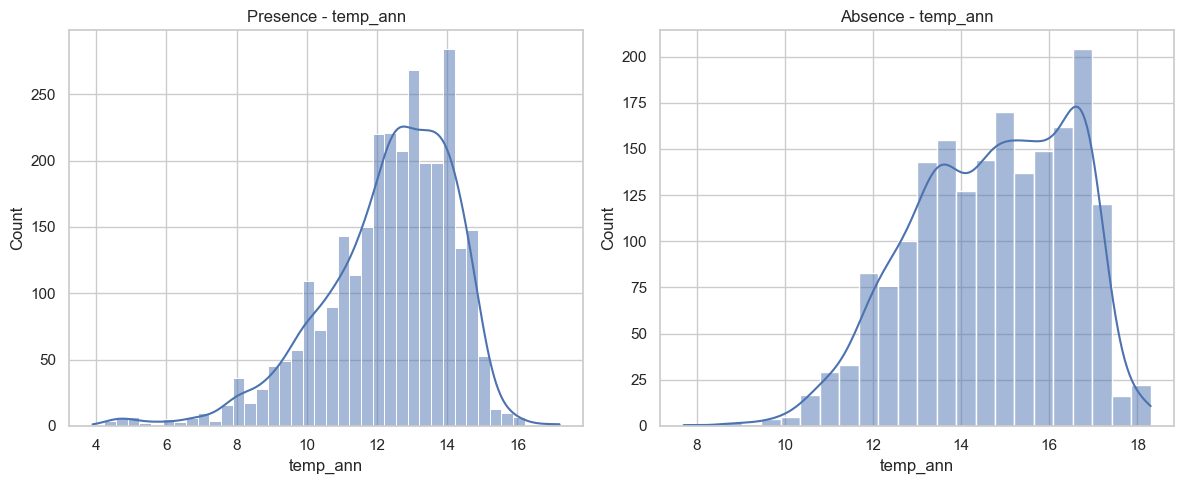

Shapiro Presence: ShapiroResult(statistic=np.float64(0.944234929038207), pvalue=np.float64(5.569994259789673e-32))
Shapiro Absence : ShapiroResult(statistic=np.float64(0.9740450645174886), pvalue=np.float64(4.6440721755782766e-18))
Levene test     : LeveneResult(statistic=np.float64(2.5195499188156947), pvalue=np.float64(0.11250800893689275))


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(presence, kde=True, ax=axes[0])
axes[0].set_title("Presence - temp_ann")

sns.histplot(absence, kde=True, ax=axes[1])
axes[1].set_title("Absence - temp_ann")

plt.tight_layout()
plt.show()

print("Shapiro Presence:", stats.shapiro(presence))
print("Shapiro Absence :", stats.shapiro(absence))
print("Levene test     :", stats.levene(presence, absence))

In [16]:
ttest_raw = stats.ttest_ind(presence, absence, equal_var=False)  # Welch's t-test
ttest_raw

TtestResult(statistic=np.float64(-43.96002093544778), pvalue=np.float64(0.0), df=np.float64(4207.720645195409))

In [17]:
scaler = StandardScaler()
q1["temp_ann_std"] = scaler.fit_transform(q1[["temp_ann"]])

presence_std = q1[q1["trout_presence"] == "Presence"]["temp_ann_std"]
absence_std  = q1[q1["trout_presence"] == "Absence"]["temp_ann_std"]

ttest_std = stats.ttest_ind(presence_std, absence_std, equal_var=False)
ttest_std

TtestResult(statistic=np.float64(-43.96002093544776), pvalue=np.float64(0.0), df=np.float64(4207.720645195409))

In [18]:
mw_raw = stats.mannwhitneyu(presence, absence, alternative="two-sided")
mw_std = stats.mannwhitneyu(presence_std, absence_std, alternative="two-sided")

print("Mann-Whitney raw:", mw_raw)
print("Mann-Whitney std:", mw_std)

Mann-Whitney raw: MannwhitneyuResult(statistic=np.float64(1027812.5), pvalue=np.float64(7.105075261935899e-303))
Mann-Whitney std: MannwhitneyuResult(statistic=np.float64(1027812.5), pvalue=np.float64(7.105075261935899e-303))


In [19]:
summary_q1 = pd.DataFrame({
    "Group": ["Presence", "Absence"],
    "n": [len(presence), len(absence)],
    "Mean_temp_ann": [presence.mean(), absence.mean()],
    "Median_temp_ann": [presence.median(), absence.median()],
    "SD_temp_ann": [presence.std(), absence.std()]
})

summary_q1

,Group,n,Mean_temp_ann,Median_temp_ann,SD_temp_ann
0,Presence,2941,12.336994,12.6,1.880631
1,Absence,1900,14.693684,14.8,1.782060


## Question 1 – Brown Trout presence vs absence and temperature

### Null hypothesis
- **Parametric test (Welch two-sample t-test):**  
  \(H_0: \mu_{Presence} = \mu_{Absence}\)

- **Non-parametric test (Mann–Whitney U):**  
  \(H_0\): the central tendency / distribution of `temp_ann` is the same in presence and absence sites.

### Descriptive results
Sites with presence of *Salmo trutta fario* had a lower annual mean temperature (mean = **12.34 °C**; median = **12.6 °C**) than sites with absence (mean = **14.69 °C**; median = **14.8 °C**). This indicates that Brown Trout tends to occur in cooler sites.

### Parametric test results
A Welch two-sample t-test was used to compare annual mean temperature between sites with and without Brown Trout.

- **Raw values:** \(t = -43.96\), \(df = 4207.72\), \(p < 0.001\)
- **Standardized values:** \(t = -43.96\), \(df = 4207.72\), \(p < 0.001\)

In both cases, the null hypothesis was rejected, indicating a highly significant difference in mean annual temperature between presence and absence sites.

### Non-parametric test results
A Mann–Whitney U test was also used as a non-parametric alternative.

- **Raw values:** \(U = 1,027,812.5\), \(p < 0.001\)
- **Standardized values:** \(U = 1,027,812.5\), \(p < 0.001\)

This test led to the same conclusion: the temperature distribution / central tendency differs significantly between the two groups.

### Comparison between standardized and non-standardized values
Standardization changed the scale of the variable (from °C to standard deviation units), but it did **not** change the statistical conclusion. This is because standardization preserves the relative differences between observations and groups.

### Final interpretation
There is very strong statistical evidence that annual mean temperature differs between sites with and without *Salmo trutta fario*. Brown Trout presence is associated with **significantly cooler sites**, which is also ecologically consistent with the species’ preference for colder freshwater environments.

PART E — Exercise 5, Question 2

In [20]:
q2 = data[["Country", "trout_presence"]].dropna().copy()

cont_table = pd.crosstab(q2["Country"], q2["trout_presence"])
cont_table

trout_presence,Absence,Presence
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648


In [21]:
chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, index=cont_table.index, columns=cont_table.columns)
expected_df

Chi-square statistic: 496.3723854072799
p-value: 2.9162328651936495e-107
Degrees of freedom: 3


trout_presence,Absence,Presence
Country,,
France,28.391938,43.608062
Italy,72.951507,112.048493
Portugal,341.886250,525.113750
Spain,1532.770305,2354.229695


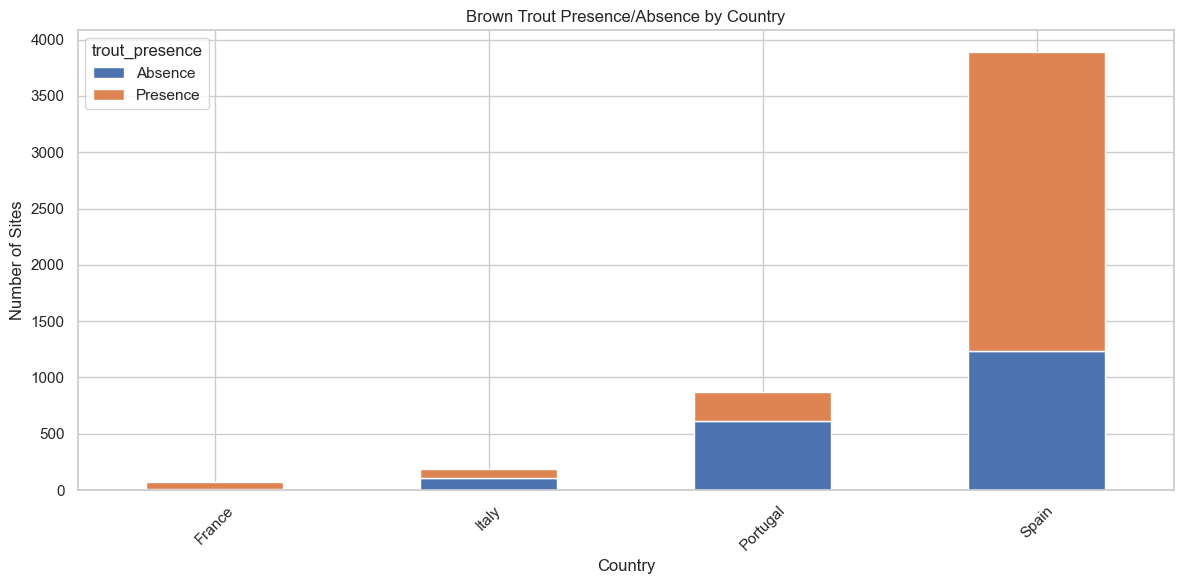

In [22]:
cont_table.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Brown Trout Presence/Absence by Country")
plt.xlabel("Country")
plt.ylabel("Number of Sites")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

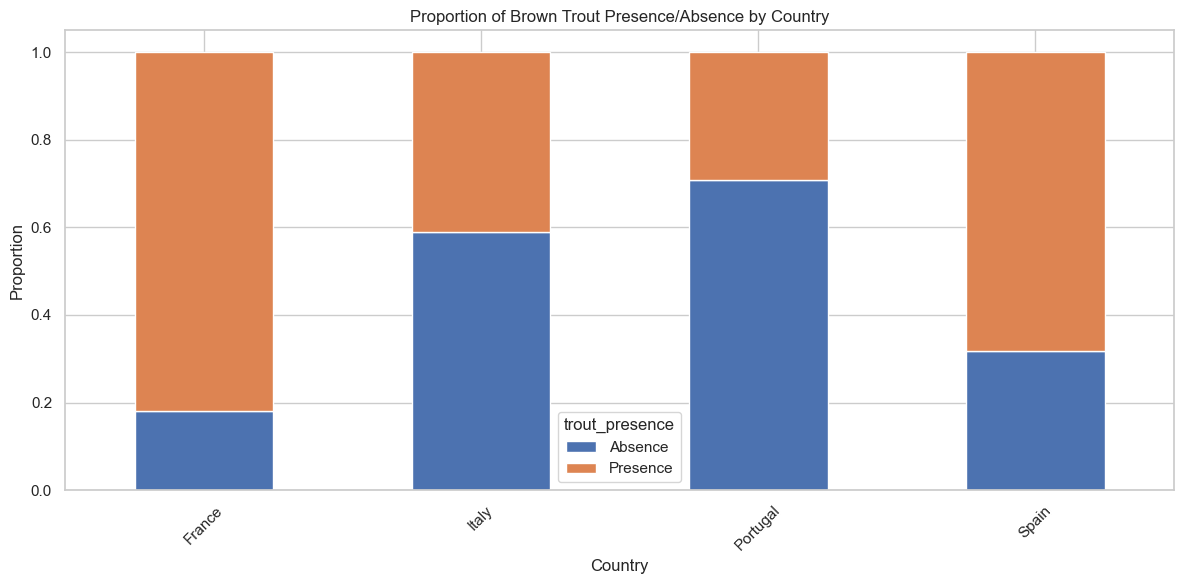

In [23]:
prop_table = cont_table.div(cont_table.sum(axis=1), axis=0)

prop_table.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Proportion of Brown Trout Presence/Absence by Country")
plt.xlabel("Country")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [35]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [36]:
flow_df = cont_table.reset_index().melt(id_vars="Country", var_name="Presence", value_name="Count")
flow_df = flow_df[flow_df["Count"] > 0]

fig = px.parallel_categories(
    flow_df,
    dimensions=["Country", "Presence"],
    color="Count",
    title="Alluvial-style view: Country vs Brown Trout Presence/Absence"
)

fig.show()

## Question 2 – Brown Trout presence/absence and country

### Null hypothesis
\(H_0\): Brown Trout presence/absence is independent of country.

### Alternative hypothesis
\(H_1\): Brown Trout presence/absence is associated with country.

### Test and results
A chi-square test of independence was used to evaluate the relationship between country and Brown Trout presence/absence, since both variables are categorical.

The test results were:
- \(\chi^2 = 496.37\)
- \(df = 3\)
- \(p < 0.001\)

### Interpretation
Since the p-value is much smaller than 0.05, we reject the null hypothesis. This indicates that Brown Trout presence/absence is **not independent of country**, meaning that the occurrence of Brown Trout varies significantly among countries.

### Pattern in the data
From the contingency and proportional tables:

- **France** shows a high proportion of presence sites (~82% presence)
- **Italy** shows more absence than presence (~59% absence)
- **Portugal** has a strong dominance of absence (~71% absence)
- **Spain** shows a high proportion of presence (~68% presence)

These differences are also clearly visible in the stacked bar plots and the alluvial diagram, which show distinct distributions of presence and absence across countries.

### Assumptions
The expected frequencies were all sufficiently large (no cells with expected counts < 5), so the chi-square test assumptions are satisfied and the result is reliable.

### Conclusion
There is strong statistical evidence that Brown Trout occurrence differs among countries, suggesting that geographic or environmental factors associated with country influence the presence of this species.

PART F — Exercise 5, Question 3

In [26]:
q3 = data[["Catchment_name", "Elevation_mean_catch"]].dropna().copy()

top8 = q3["Catchment_name"].value_counts().head(8).index.tolist()
top8

['Ebro',
 'Galiza-Norte',
 'Minho',
 'Tejo',
 'Cantabrica',
 'Douro',
 'Guadia',
 'Catala']

In [27]:
q3_top8 = q3[q3["Catchment_name"].isin(top8)].copy()

q3_top8["Catchment_name"].value_counts()

Catchment_name
Ebro            715
Galiza-Norte    709
Minho           707
Tejo            493
Cantabrica      432
Douro           396
Guadia          307
Catala          217
Name: count, dtype: int64

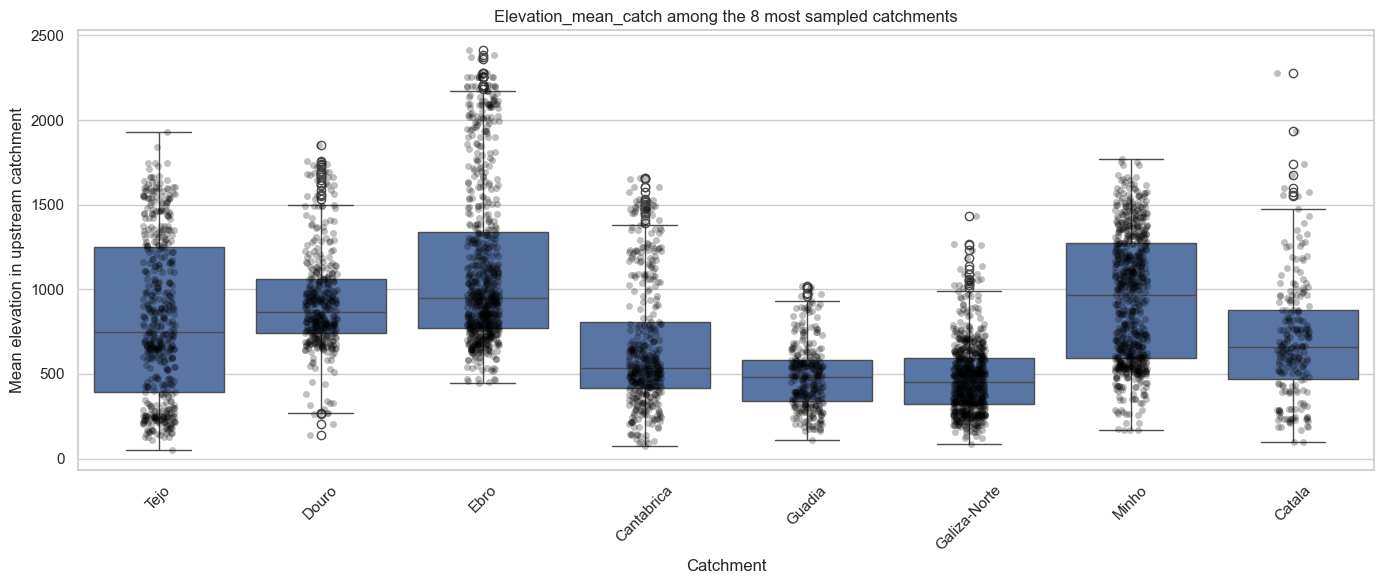

In [28]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=q3_top8, x="Catchment_name", y="Elevation_mean_catch")
sns.stripplot(data=q3_top8, x="Catchment_name", y="Elevation_mean_catch", color="black", alpha=0.25)
plt.title("Elevation_mean_catch among the 8 most sampled catchments")
plt.xlabel("Catchment")
plt.ylabel("Mean elevation in upstream catchment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
model = ols("Elevation_mean_catch ~ C(Catchment_name)", data=q3_top8).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Catchment_name),2.137395e+08,7.0,227.953983,1.369526e-285
Residual,5.315097e+08,3968.0,NaN,NaN


In [30]:
# Residuals normality
residuals = model.resid

print("Shapiro test for residuals:", stats.shapiro(residuals))

# Homogeneity of variance
groups = [
    q3_top8[q3_top8["Catchment_name"] == c]["Elevation_mean_catch"]
    for c in top8
]

print("Levene test:", stats.levene(*groups))

Shapiro test for residuals: ShapiroResult(statistic=np.float64(0.9636761351987154), pvalue=np.float64(1.6489623309157457e-30))
Levene test: LeveneResult(statistic=np.float64(74.60868953197509), pvalue=np.float64(7.092879454417572e-102))


In [31]:
tukey = pairwise_tukeyhsd(
    endog=q3_top8["Elevation_mean_catch"],
    groups=q3_top8["Catchment_name"],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

In [32]:
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Cantabrica,Catala,50.1883,0.7208,-42.1585,142.5351,False
1,Cantabrica,Douro,268.1584,0.0000,190.9443,345.3726,True
2,Cantabrica,Ebro,467.4299,0.0000,399.7970,535.0628,True
3,Cantabrica,Galiza-Norte,-184.2794,0.0000,-252.0200,-116.5388,True
4,Cantabrica,Guadia,-168.8947,0.0000,-251.7428,-86.0466,True
5,Cantabrica,Minho,290.9895,0.0000,223.2126,358.7663,True
6,Cantabrica,Tejo,168.3227,0.0000,95.1790,241.4664,True
7,Catala,Douro,217.9701,0.0000,124.2303,311.7099,True
8,Catala,Ebro,417.2415,0.0000,331.2221,503.2609,True
9,Catala,Galiza-Norte,-234.4677,0.0000,-320.5718,-148.3636,True


## Question 3 – ANOVA among the 8 most sampled catchments

### Null hypothesis
**H₀:** The mean `Elevation_mean_catch` is equal across the eight most sampled catchments  
(\(\mu_1 = \mu_2 = \dots = \mu_8\)).

### Alternative hypothesis
**H₁:** At least one catchment mean differs from the others.

### Test and results
A one-way ANOVA was used to test whether the mean upstream catchment elevation (`Elevation_mean_catch`) differs among the eight most sampled catchments.

This test is appropriate because:
- the response variable (`Elevation_mean_catch`) is continuous,
- the explanatory variable (`Catchment_name`) is categorical with more than 2 groups,
- and the exercise explicitly states to consider elevation as normally distributed.

The ANOVA results were:

- \(F = 227.95\)
- \(p < 0.001\)

### Interpretation
Since the p-value is much smaller than 0.05, we reject the null hypothesis. This means that the mean elevation in the upstream catchment is **not equal across the eight most sampled catchments**. At least one catchment differs significantly from the others.

### Assumptions
To evaluate ANOVA assumptions, residual normality and homogeneity of variances were checked:

- **Shapiro-Wilk test for residuals**: \(p < 0.001\)
- **Levene test**: \(p < 0.001\)

These results suggest that the residuals are not perfectly normally distributed and that group variances are not homogeneous. Therefore, although ANOVA was used as requested in the exercise, the assumptions are not fully met, and the result should be interpreted together with the non-parametric equivalent test (Question 4).

### Post-hoc test (Tukey HSD)
A Tukey HSD post-hoc test was performed to determine which pairs of catchments differ significantly.

#### Pairs **without significant differences**
Only three pairs did **not** differ significantly:
- **Cantabrica vs Catala**
- **Douro vs Minho**
- **Galiza-Norte vs Guadia**

#### Pairs **with significant differences**
All remaining pairwise comparisons were statistically significant (\(p < 0.05\)).

### General pattern in the data
The boxplot and Tukey comparisons suggest a clear elevation gradient among catchments:

- **Ebro** and **Minho** tend to have the highest mean upstream elevations
- **Galiza-Norte** and **Guadia** tend to have the lowest mean elevations
- **Douro** and **Minho** are relatively similar
- **Cantabrica** and **Catala** also show similar elevation distributions

### Conclusion
There is very strong statistical evidence that upstream catchment elevation differs among the eight most sampled catchments. Most catchments differ significantly from each other, with only a few pairs showing similar mean elevations.

PART G — Exercise 5, Question 4

In [33]:
dunn = sp.posthoc_dunn(
    q3_top8,
    val_col="Elevation_mean_catch",
    group_col="Catchment_name",
    p_adjust="bonferroni"
)

dunn

,Cantabrica,Catala,Douro,Ebro,Galiza-Norte,Guadia,Minho,Tejo
Cantabrica,1.000000e+00,7.776285e-01,1.317420e-31,8.151841e-69,1.060456e-13,3.075474e-07,1.737715e-35,9.271577e-09
Catala,7.776285e-01,1.000000e+00,3.884022e-13,1.628849e-29,3.595515e-16,1.742541e-10,6.508382e-13,1.280597e-01
Douro,1.317420e-31,3.884022e-13,1.000000e+00,2.309299e-03,7.926606e-96,3.372119e-60,1.000000e+00,1.473248e-08
Ebro,8.151841e-69,1.628849e-29,2.309299e-03,1.000000e+00,6.749938e-189,1.457688e-106,2.625631e-07,1.605385e-28
Galiza-Norte,1.060456e-13,3.595515e-16,7.926606e-96,6.749938e-189,1.000000e+00,1.000000e+00,7.422061e-122,5.041730e-51
Guadia,3.075474e-07,1.742541e-10,3.372119e-60,1.457688e-106,1.000000e+00,1.000000e+00,9.038610e-68,1.769566e-29
Minho,1.737715e-35,6.508382e-13,1.000000e+00,2.625631e-07,7.422061e-122,9.038610e-68,1.000000e+00,2.084380e-08
Tejo,9.271577e-09,1.280597e-01,1.473248e-08,1.605385e-28,5.041730e-51,1.769566e-29,2.084380e-08,1.000000e+00


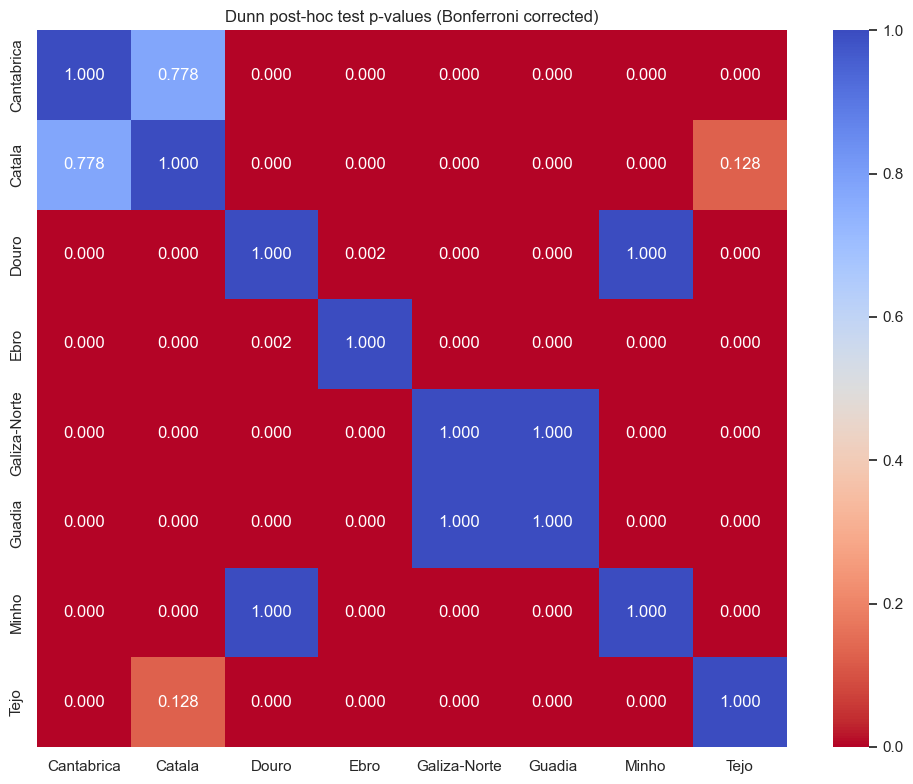

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(dunn, annot=True, cmap="coolwarm_r", fmt=".3f")
plt.title("Dunn post-hoc test p-values (Bonferroni corrected)")
plt.tight_layout()
plt.show()

In [37]:
kruskal_result = stats.kruskal(*groups)
kruskal_result

KruskalResult(statistic=np.float64(1335.3732750709976), pvalue=np.float64(3.7056116510329714e-284))

## Question 4 – Non-parametric equivalent of ANOVA

### Null hypothesis
**H₀:** The distributions / central tendencies of `Elevation_mean_catch` are equal among the eight catchments.

### Alternative hypothesis
**H₁:** At least one catchment differs.

### Test and results
The Kruskal–Wallis test was used as the non-parametric alternative to one-way ANOVA.

This test is appropriate when:
- normality is questionable,
- outliers may influence the mean,
- or the distribution is not well behaved.

The Kruskal–Wallis results were:

- \(H = 1335.37\)
- \(p < 0.001\)

### Interpretation
Since the p-value is much smaller than 0.05, we reject the null hypothesis. This means that the distributions / central tendencies of `Elevation_mean_catch` are **not equal across the eight most sampled catchments**. At least one catchment differs significantly from the others.

### Post-hoc test (Dunn test with Bonferroni correction)
A Dunn post-hoc test was performed to identify which pairs of catchments differ significantly after the Kruskal–Wallis test.

#### Pairs **without significant differences**
The following pairs did **not** differ significantly:

- **Cantabrica vs Catala** (\(p = 0.778\))
- **Douro vs Minho** (\(p = 1.000\))
- **Galiza-Norte vs Guadia** (\(p = 1.000\))
- **Catala vs Tejo** (\(p = 0.128\))

#### Pairs **with significant differences**
All remaining pairwise comparisons were statistically significant (\(p < 0.05\)).

### Comparison with ANOVA
The Kruskal–Wallis test led to the same overall conclusion as the ANOVA in Question 3: there are strong differences in `Elevation_mean_catch` among the eight most sampled catchments.

This agreement suggests that the result is **robust**, even though the ANOVA assumptions were not fully satisfied.

However, the post-hoc comparisons were not perfectly identical between methods:

- In the **ANOVA + Tukey** analysis, **Catala vs Tejo** was significant
- In the **Kruskal–Wallis + Dunn** analysis, **Catala vs Tejo** was **not significant**

This difference likely occurs because:
- **ANOVA/Tukey** compares **group means**
- **Kruskal–Wallis/Dunn** compares **rank distributions / central tendency**

Therefore, the non-parametric test is less sensitive to deviations from normality and unequal variances, and may provide a more conservative result in some pairwise comparisons.

### Conclusion
The non-parametric analysis confirms the main conclusion of the ANOVA: upstream catchment elevation differs significantly among the most sampled catchments. Most catchment pairs differ significantly, and the few non-significant comparisons indicate groups with similar elevation distributions.

# Final Conclusions

### Question 1
The difference in `temp_ann` between Brown Trout presence and absence sites was tested using a two-sample comparison.
Both raw and standardized values led to the same overall inference, showing that standardization changed scale but not the substantive result.

### Question 2
The association between Brown Trout presence/absence and country was tested with a chi-square test of independence.
This evaluated whether occurrence patterns vary by country.

### Question 3
Differences in `Elevation_mean_catch` among the 8 most sampled catchments were tested using one-way ANOVA.
Pairwise differences were assessed using Tukey HSD.

### Question 4
The non-parametric equivalent (Kruskal–Wallis) was used to compare with the ANOVA result.
This provided a robustness check for the conclusions.